# Planck plik_lite CMB Covariance for Lensing

Compute the Eq. 34 modified covariance contribution from Planck CMB uncertainties.

**Data source:** `/scratch/jiaqu/likelihood_data/data/planck_2018_pliklite_native/`

**Key difference from ACT:** Planck bins are narrower (~10-50 ells) and cover lower ell range.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5

%config InlineBackend.figure_format='retina'

## 1. Load Planck plik_lite Data

In [3]:
# Planck plik_lite data directory
planck_dir = '/scratch/jiaqu/likelihood_data/data/planck_2018_pliklite_native/'

# Load bandpowers (613 bins: ell_center, Cl, sigma)
# Structure: TT (215 bins) + TE (199 bins) + EE (199 bins) = 613 total
planck_data = np.loadtxt(os.path.join(planck_dir, 'cl_cmb_plik_v22.dat'))
print(f"Planck data shape: {planck_data.shape}")

# Bin structure
n_TT, n_TE, n_EE = 215, 199, 199
n_total = n_TT + n_TE + n_EE

# Extract spectra
planck_TT = {
    'ell': planck_data[:n_TT, 0],
    'Cl': planck_data[:n_TT, 1],
    'sigma': planck_data[:n_TT, 2]
}
planck_TE = {
    'ell': planck_data[n_TT:n_TT+n_TE, 0],
    'Cl': planck_data[n_TT:n_TT+n_TE, 1],
    'sigma': planck_data[n_TT:n_TT+n_TE, 2]
}
planck_EE = {
    'ell': planck_data[n_TT+n_TE:, 0],
    'Cl': planck_data[n_TT+n_TE:, 1],
    'sigma': planck_data[n_TT+n_TE:, 2]
}

print(f"TT: {n_TT} bins, ell = {planck_TT['ell'].min():.0f} - {planck_TT['ell'].max():.0f}")
print(f"TE: {n_TE} bins, ell = {planck_TE['ell'].min():.0f} - {planck_TE['ell'].max():.0f}")
print(f"EE: {n_EE} bins, ell = {planck_EE['ell'].min():.0f} - {planck_EE['ell'].max():.0f}")

Planck data shape: (613, 3)
TT: 215 bins, ell = 32 - 2492
TE: 199 bins, ell = 32 - 1988
EE: 199 bins, ell = 32 - 1988


In [4]:
# Load bin edges
blmin = np.loadtxt(os.path.join(planck_dir, 'blmin.dat')).astype(int)
blmax = np.loadtxt(os.path.join(planck_dir, 'blmax.dat')).astype(int)

print(f"Bin edges loaded: {len(blmin)} bins")
print(f"First 5 bins: blmin={blmin[:5]}, blmax={blmax[:5]}")
print(f"Bin widths (first 10): {blmax[:10] - blmin[:10] + 1}")

Bin edges loaded: 645 bins
First 5 bins: blmin=[ 0  5 10 15 20], blmax=[ 4  9 14 19 24]
Bin widths (first 10): [5 5 5 5 5 5 5 5 5 5]


In [5]:
# Load covariance matrix (613 x 613) - Fortran binary format
from scipy.io import FortranFile

f = FortranFile(os.path.join(planck_dir, 'c_matrix_plik_v22.dat'), 'r')
cov_data = f.read_reals(dtype='float64')
f.close()

cov_planck_full = cov_data.reshape((613, 613))
print(f"Planck covariance shape: {cov_planck_full.shape}")

# Extract diagonal blocks
cov_TT_TT = cov_planck_full[:n_TT, :n_TT]
cov_TE_TE = cov_planck_full[n_TT:n_TT+n_TE, n_TT:n_TT+n_TE]
cov_EE_EE = cov_planck_full[n_TT+n_TE:, n_TT+n_TE:]

# Cross-spectrum blocks
cov_TT_TE = cov_planck_full[:n_TT, n_TT:n_TT+n_TE]
cov_TT_EE = cov_planck_full[:n_TT, n_TT+n_TE:]
cov_TE_EE = cov_planck_full[n_TT:n_TT+n_TE, n_TT+n_TE:]

print(f"\nDiagonal blocks:")
print(f"  TT-TT: {cov_TT_TT.shape}, diag range: [{cov_TT_TT.diagonal().min():.2e}, {cov_TT_TT.diagonal().max():.2e}]")
print(f"  TE-TE: {cov_TE_TE.shape}, diag range: [{cov_TE_TE.diagonal().min():.2e}, {cov_TE_TE.diagonal().max():.2e}]")
print(f"  EE-EE: {cov_EE_EE.shape}, diag range: [{cov_EE_EE.diagonal().min():.2e}, {cov_EE_EE.diagonal().max():.2e}]")

# Verify sigma matches sqrt(diag)
sigma_check = np.sqrt(cov_TT_TT.diagonal()[:5])
print(f"\nSigma check (TT first 5): file={planck_TT['sigma'][:5]}, sqrt(diag)={sigma_check}")

Planck covariance shape: (613, 613)

Diagonal blocks:
  TT-TT: (215, 215), diag range: [3.01e-10, 4.80e-01]
  TE-TE: (199, 199), diag range: [1.14e-10, 7.73e-05]
  EE-EE: (199, 199), diag range: [1.05e-10, 5.14e-08]

Sigma check (TT first 5): file=[0.69310479 0.51873081 0.40830572 0.33215266 0.27661617], sqrt(diag)=[0.69310479 0.51873081 0.40830572 0.33215266 0.27661617]


## 2. Load Fiducial Theory and Plot

In [6]:
# Load fiducial CMB spectra (same as other notebooks)
like_corrs_dir = '/home/jiaqu/spt_act_likelihood/act_dr6_spt_lenslike/data/v1.2/like_corrs/'
fid_cmb = np.loadtxt(os.path.join(like_corrs_dir, 'cosmo2017_10K_acc3_lensedCls.dat'))

fid_ells = fid_cmb[:, 0]
# Fiducial is in Dl units, convert to Cl
ell_factor = fid_ells * (fid_ells + 1) / (2 * np.pi)
ell_factor[0] = 1  # avoid division by zero

fid_Cl = {
    'TT': fid_cmb[:, 1] / ell_factor,
    'EE': fid_cmb[:, 2] / ell_factor,
    'TE': fid_cmb[:, 4] / ell_factor,
}
fid_Dl = {
    'TT': fid_cmb[:, 1],
    'EE': fid_cmb[:, 2],
    'TE': fid_cmb[:, 4],
}

print(f"Fiducial ell range: {fid_ells.min():.0f} - {fid_ells.max():.0f}")

Fiducial ell range: 2 - 8250


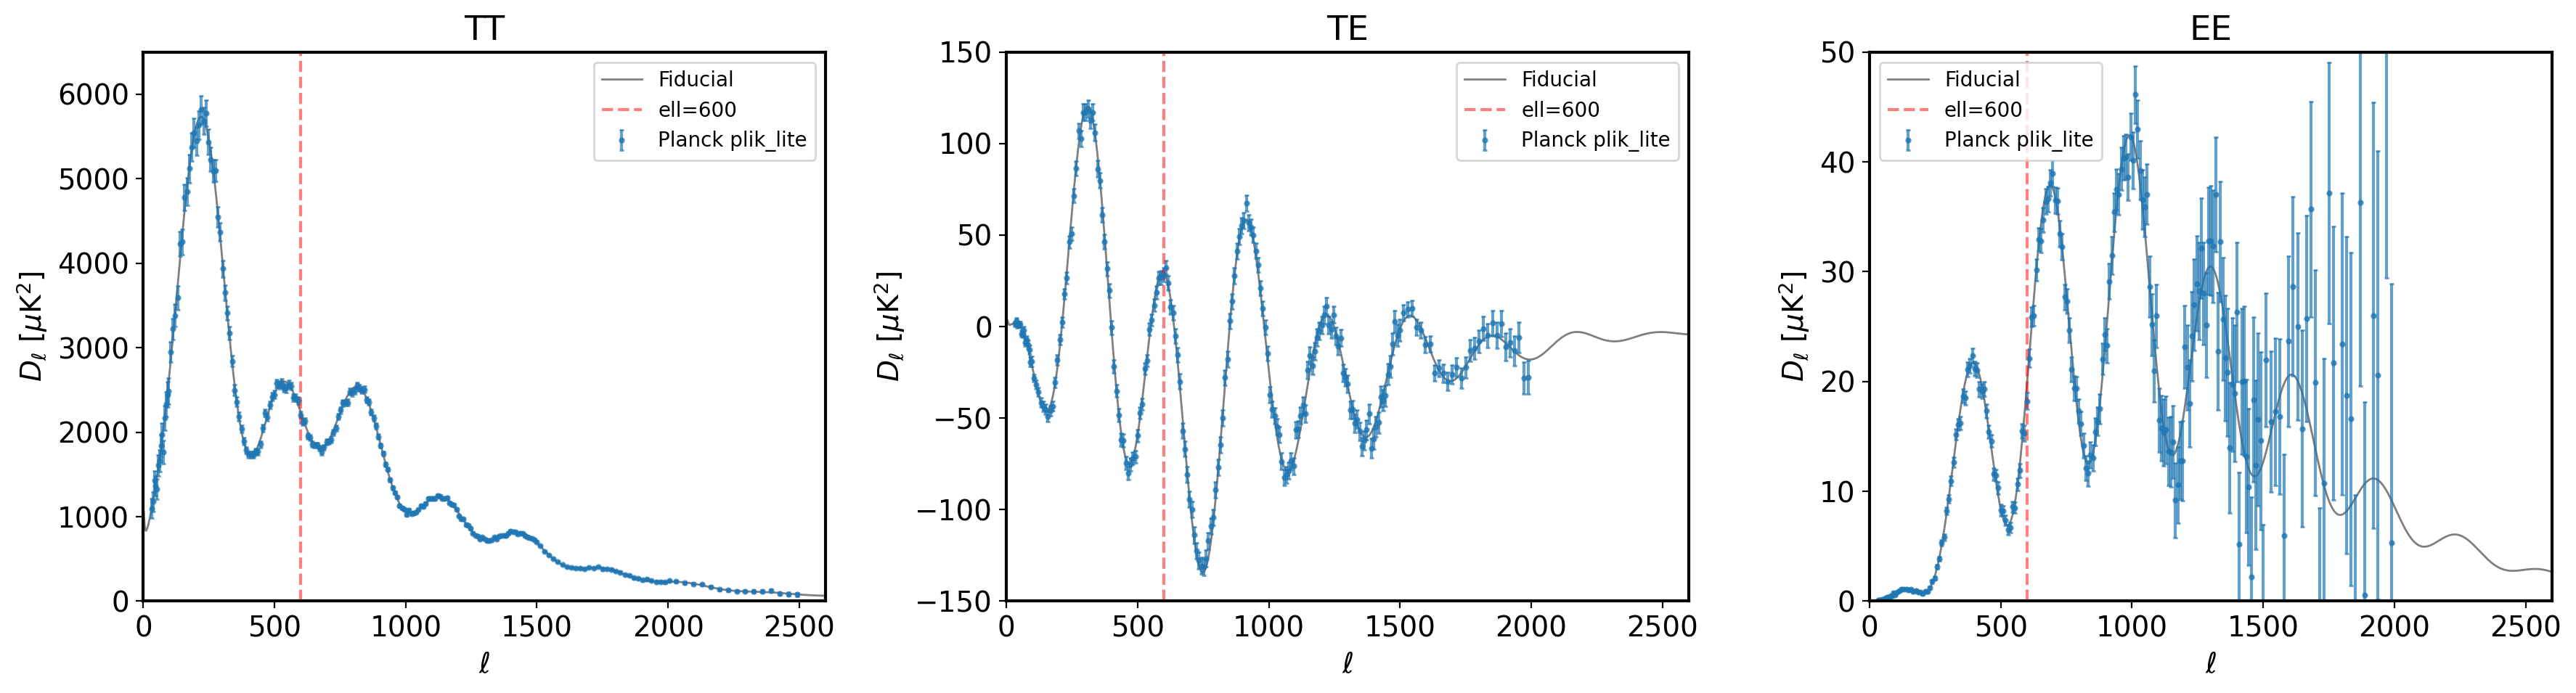

Saved: planck_theory_vs_data.png


In [7]:
# Convert Planck Cl to Dl for plotting
planck_Dl = {}
planck_Dl_err = {}
for name, data in [('TT', planck_TT), ('TE', planck_TE), ('EE', planck_EE)]:
    ell = data['ell']
    factor = ell * (ell + 1) / (2 * np.pi)
    planck_Dl[name] = data['Cl'] * factor
    planck_Dl_err[name] = data['sigma'] * factor

# Plot theory vs Planck
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ['TT', 'TE', 'EE']):
    # Theory
    ax.plot(fid_ells, fid_Dl[name], 'k-', lw=1, alpha=0.5, label='Fiducial')
    
    # Planck data
    if name == 'TT':
        ell_data = planck_TT['ell']
    elif name == 'TE':
        ell_data = planck_TE['ell']
    else:
        ell_data = planck_EE['ell']
    
    ax.errorbar(ell_data, planck_Dl[name], yerr=planck_Dl_err[name],
                fmt='o', markersize=2, capsize=1, alpha=0.7, label='Planck plik_lite')
    
    # Mark ell=600 (M matrix lmin)
    ax.axvline(600, color='r', ls='--', alpha=0.5, label='ell=600')
    
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$D_\ell$ [$\mu$K$^2$]')
    ax.set_title(f'{name}')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 2600)
    
    if name == 'TT':
        ax.set_ylim(0, 6500)
    elif name == 'TE':
        ax.set_ylim(-150, 150)
    else:
        ax.set_ylim(0, 50)

plt.tight_layout()
plt.savefig('planck_theory_vs_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: planck_theory_vs_data.png")

## 3. Load Likelihood Correction Matrices

In [8]:
# Load M matrices (same as other notebooks)
like_corrs_dir = '/home/jiaqu/spt_act_likelihood/act_dr6_spt_lenslike/data/v1.2/like_corrs/'

# Fiducial A_L normalization
fAL_data = np.loadtxt(f'{like_corrs_dir}/n0mv_fiducial_lmin600_lmax3000_Lmin0_Lmax4000.txt')
fAL = fAL_data[1, :]  # Shape: (4001,)
print(f"fAL shape: {fAL.shape}")

# dA_L/dC norm correction matrix: shape (4, 4001, 3001)
dAL_dC = np.load(f'{like_corrs_dir}/norm_correction_matrix_Lmin0_Lmax4000.npy')
print(f"dAL_dC shape: {dAL_dC.shape}")

# N1 derivatives
dN1_TT = np.loadtxt(f'{like_corrs_dir}/N1der_TT_lmin600_lmax3000_full.txt')
dN1_EE = np.loadtxt(f'{like_corrs_dir}/N1der_EE_lmin600_lmax3000_full.txt')
dN1_TE = np.loadtxt(f'{like_corrs_dir}/N1der_TE_lmin600_lmax3000_full.txt')
print(f"N1 derivatives shape: {dN1_TT.shape}")

# Fiducial clkk
fid_lens = np.loadtxt(f'{like_corrs_dir}/cosmo2017_10K_acc3_lenspotentialCls.dat')
clpp_fid = fid_lens[:, 5]
clkk_fid = clpp_fid * 2 * np.pi / 4
clkk_fid_trunc = clkk_fid[:4001]
print(f"clkk_fid shape: {clkk_fid_trunc.shape}")

fAL shape: (4001,)
dAL_dC shape: (4, 4001, 3001)
N1 derivatives shape: (3000, 3000)
clkk_fid shape: (4001,)


In [9]:
# Build M matrices
def build_M_matrix(dAL_dC_X, dN1_X, fAL, clkk_fid_trunc, Lmax=3000):
    """Build M matrix for spectrum X.
    
    M^X_L,ell = -2 * dAL_dC[L, ell] / fAL[L] * clkk_fid[L] + dN1_X[L, ell]
    """
    M = np.zeros((Lmax, 3000))
    for L in range(2, Lmax):
        if fAL[L] > 0:
            M[L, :] = -2 * dAL_dC_X[L, :3000] / fAL[L] * clkk_fid_trunc[L]
        M[L, :] += dN1_X[L, :]
    return M

print("Building M matrices...")
M_TT = build_M_matrix(dAL_dC[0], dN1_TT, fAL, clkk_fid_trunc)
M_EE = build_M_matrix(dAL_dC[1], dN1_EE, fAL, clkk_fid_trunc)
M_TE = build_M_matrix(dAL_dC[3], dN1_TE, fAL, clkk_fid_trunc)
print(f"M matrix shape: {M_TT.shape}")

# Bin M along lensing L dimension
ddir = '/home/jiaqu/spt_act_likelihood/act_dr6_spt_lenslike/data/v1.2/'
lens_binmat = np.loadtxt(f'{ddir}/binning_matrix_act.txt')
print(f"Lensing binning matrix shape: {lens_binmat.shape}")

Lmax_lens = lens_binmat.shape[1]
M_TT_binned = lens_binmat @ M_TT[:Lmax_lens, :]
M_EE_binned = lens_binmat @ M_EE[:Lmax_lens, :]
M_TE_binned = lens_binmat @ M_TE[:Lmax_lens, :]
print(f"M binned shape: {M_TT_binned.shape}")

Building M matrices...
M matrix shape: (3000, 3000)
Lensing binning matrix shape: (18, 3000)
M binned shape: (18, 3000)


## 4. Rebin M to Planck Super-bins (Δℓ ≈ 50 Smoothness Assumption)

From the Planck lensing paper: "we assume that the underlying CMB power spectra are represented only by modes that are smooth over Δℓ = 50"

**Approach**: Group narrow plik_lite bins (~10 ells each) into "super-bins" of ~50 ells to avoid overlapping M windows. Then aggregate both M and covariance to super-bin space.

In [10]:
# Group plik_lite bins into super-bins of ~50 ells
# This avoids overlapping M windows that cause double-counting

DELTA_ELL = 50  # Target super-bin width

# For each spectrum, find bins with ell >= 600 and group them
superbin_info = {}

for spec, n_bins, ell_data in [('TT', n_TT, planck_TT['ell']), 
                                ('TE', n_TE, planck_TE['ell']), 
                                ('EE', n_EE, planck_EE['ell'])]:
    
    # Find active bins (ell >= 600)
    active_mask = ell_data >= 600
    active_indices = np.where(active_mask)[0]
    active_ells = ell_data[active_mask]
    
    if len(active_indices) == 0:
        superbin_info[spec] = {'n_superbins': 0, 'mapping': [], 'ell_ranges': []}
        continue
    
    # Determine bin spacing (average ell difference between adjacent bins)
    if len(active_ells) > 1:
        avg_bin_spacing = np.mean(np.diff(active_ells))
    else:
        avg_bin_spacing = 10
    
    # How many plik_lite bins per super-bin?
    bins_per_superbin = max(1, int(round(DELTA_ELL / avg_bin_spacing)))
    
    # Create super-bin mapping
    n_superbins = len(active_indices) // bins_per_superbin
    if n_superbins == 0:
        n_superbins = 1
        bins_per_superbin = len(active_indices)
    
    mapping = []  # List of (start_plik_idx, end_plik_idx) for each super-bin
    ell_ranges = []
    
    for sb in range(n_superbins):
        start_pos = sb * bins_per_superbin
        end_pos = min((sb + 1) * bins_per_superbin, len(active_indices))
        
        plik_start = active_indices[start_pos]
        plik_end = active_indices[end_pos - 1]
        
        mapping.append((plik_start, plik_end))
        ell_ranges.append((ell_data[plik_start], ell_data[plik_end]))
    
    superbin_info[spec] = {
        'n_superbins': n_superbins,
        'mapping': mapping,
        'ell_ranges': ell_ranges,
        'bins_per_superbin': bins_per_superbin,
        'active_indices': active_indices
    }
    
    print(f"{spec}: {len(active_indices)} active plik_lite bins -> {n_superbins} super-bins")
    print(f"     {bins_per_superbin} plik_lite bins per super-bin (~{bins_per_superbin * avg_bin_spacing:.0f} ells)")
    print(f"     ell range: {ell_ranges[0][0]:.0f} - {ell_ranges[-1][1]:.0f}")

TT: 145 active plik_lite bins -> 36 super-bins
     4 plik_lite bins per super-bin (~52 ells)
     ell range: 608 - 2459
TE: 129 active plik_lite bins -> 25 super-bins
     5 plik_lite bins per super-bin (~54 ells)
     ell range: 608 - 1920
EE: 129 active plik_lite bins -> 25 super-bins
     5 plik_lite bins per super-bin (~54 ells)
     ell range: 608 - 1920


In [11]:
# Build M_doubly for super-bins: sum M over ell range of each super-bin

M_doubly_superbin = {}

for spec, M_binned in [('TT', M_TT_binned), ('TE', M_TE_binned), ('EE', M_EE_binned)]:
    info = superbin_info[spec]
    n_superbins = info['n_superbins']
    n_lens_bins = M_binned.shape[0]
    
    M_doubly_superbin[spec] = np.zeros((n_lens_bins, n_superbins))
    
    for sb, (ell_start, ell_end) in enumerate(info['ell_ranges']):
        ell_start_int = int(ell_start)
        ell_end_int = min(int(ell_end) + 1, M_binned.shape[1])  # +1 for inclusive
        
        # Sum M over super-bin ell range
        M_doubly_superbin[spec][:, sb] = np.sum(M_binned[:, ell_start_int:ell_end_int], axis=1)
    
    print(f"{spec}: M_doubly_superbin shape = {M_doubly_superbin[spec].shape}")
    print(f"     M range: [{M_doubly_superbin[spec].min():.2e}, {M_doubly_superbin[spec].max():.2e}]")

TT: M_doubly_superbin shape = (18, 36)
     M range: [-1.57e-04, 3.12e-04]
TE: M_doubly_superbin shape = (18, 25)
     M range: [-3.36e-04, 2.56e-04]
EE: M_doubly_superbin shape = (18, 25)
     M range: [-7.50e-04, 5.61e-04]


## 5. Aggregate Covariance to Super-bins

In [12]:
# Aggregate plik_lite covariance to super-bin covariance
# For each pair of super-bins, sum the covariance over all plik_lite bin pairs

def aggregate_cov_to_superbins(cov_plik, mapping1, mapping2):
    """Aggregate plik_lite covariance to super-bin covariance.
    
    cov_superbin[sb1, sb2] = sum_{i in sb1, j in sb2} cov_plik[i, j]
    """
    n_sb1 = len(mapping1)
    n_sb2 = len(mapping2)
    cov_superbin = np.zeros((n_sb1, n_sb2))
    
    for sb1, (plik_start1, plik_end1) in enumerate(mapping1):
        for sb2, (plik_start2, plik_end2) in enumerate(mapping2):
            # Sum covariance over all plik_lite bins in these super-bins
            cov_superbin[sb1, sb2] = np.sum(
                cov_plik[plik_start1:plik_end1+1, plik_start2:plik_end2+1]
            )
    
    return cov_superbin

# Build super-bin covariance blocks
cov_superbin = {}

# Diagonal blocks
cov_superbin[('TT', 'TT')] = aggregate_cov_to_superbins(
    cov_TT_TT, superbin_info['TT']['mapping'], superbin_info['TT']['mapping'])
cov_superbin[('TE', 'TE')] = aggregate_cov_to_superbins(
    cov_TE_TE, superbin_info['TE']['mapping'], superbin_info['TE']['mapping'])
cov_superbin[('EE', 'EE')] = aggregate_cov_to_superbins(
    cov_EE_EE, superbin_info['EE']['mapping'], superbin_info['EE']['mapping'])

# Cross-spectrum blocks
cov_superbin[('TT', 'TE')] = aggregate_cov_to_superbins(
    cov_TT_TE, superbin_info['TT']['mapping'], superbin_info['TE']['mapping'])
cov_superbin[('TT', 'EE')] = aggregate_cov_to_superbins(
    cov_TT_EE, superbin_info['TT']['mapping'], superbin_info['EE']['mapping'])
cov_superbin[('TE', 'EE')] = aggregate_cov_to_superbins(
    cov_TE_EE, superbin_info['TE']['mapping'], superbin_info['EE']['mapping'])

# Transpose blocks
cov_superbin[('TE', 'TT')] = cov_superbin[('TT', 'TE')].T
cov_superbin[('EE', 'TT')] = cov_superbin[('TT', 'EE')].T
cov_superbin[('EE', 'TE')] = cov_superbin[('TE', 'EE')].T

print("Super-bin covariance blocks:")
for key in [('TT', 'TT'), ('TE', 'TE'), ('EE', 'EE')]:
    cov = cov_superbin[key]
    print(f"  {key}: shape {cov.shape}, diag range: [{cov.diagonal().min():.2e}, {cov.diagonal().max():.2e}]")

Super-bin covariance blocks:
  ('TT', 'TT'): shape (36, 36), diag range: [2.61e-09, 1.35e-06]
  ('TE', 'TE'): shape (25, 25), diag range: [5.66e-10, 1.94e-08]
  ('EE', 'EE'): shape (25, 25), diag range: [5.34e-10, 4.69e-09]


## 6. Compute Eq. 34 Modified Covariance (Planck Super-bins)

In [13]:
# Load original lensing covariance
lens_cov_orig = np.loadtxt(f'{ddir}/covmat_act.txt')
n_lens_bins = lens_cov_orig.shape[0]
print(f"Original lensing covariance: {lens_cov_orig.shape}")

# Compute covariance addition from Planck using super-bins
cov_add_planck = np.zeros((n_lens_bins, n_lens_bins))

# 9 terms: TT-TT, TT-TE, TT-EE, TE-TT, TE-TE, TE-EE, EE-TT, EE-TE, EE-EE
for spec1 in ['TT', 'TE', 'EE']:
    for spec2 in ['TT', 'TE', 'EE']:
        M1 = M_doubly_superbin[spec1]
        M2 = M_doubly_superbin[spec2]
        cov_block = cov_superbin[(spec1, spec2)]
        
        term = M1 @ cov_block @ M2.T
        cov_add_planck += term

print(f"\nCovariance addition (Planck super-bins):")
print(f"  diag min={np.diag(cov_add_planck).min():.2e}, max={np.diag(cov_add_planck).max():.2e}")

# Modified covariance
lens_cov_modified_planck = lens_cov_orig + cov_add_planck

# Diagonal increase
diag_increase_planck = (np.diag(lens_cov_modified_planck) - np.diag(lens_cov_orig)) / np.diag(lens_cov_orig) * 100

print(f"\nPlanck diagonal increase (%):")
print(f"  Max: {diag_increase_planck.max():.3f}%")
print(f"  Mean: {diag_increase_planck.mean():.3f}%")
print(f"  Per bin: {np.round(diag_increase_planck, 2)}")

Original lensing covariance: (18, 18)

Covariance addition (Planck super-bins):
  diag min=6.34e-19, max=5.06e-15

Planck diagonal increase (%):
  Max: 3043.675%
  Mean: 715.337%
  Per bin: [ 213.48  899.26 1752.3  3040.98 3043.67 1925.94  783.35  307.13  271.4
  244.73  176.64   73.4    37.23   25.82   23.95   22.35   23.05   11.36]


## 7. Compare with Other Approaches

NameError: name 'have_dr6' is not defined

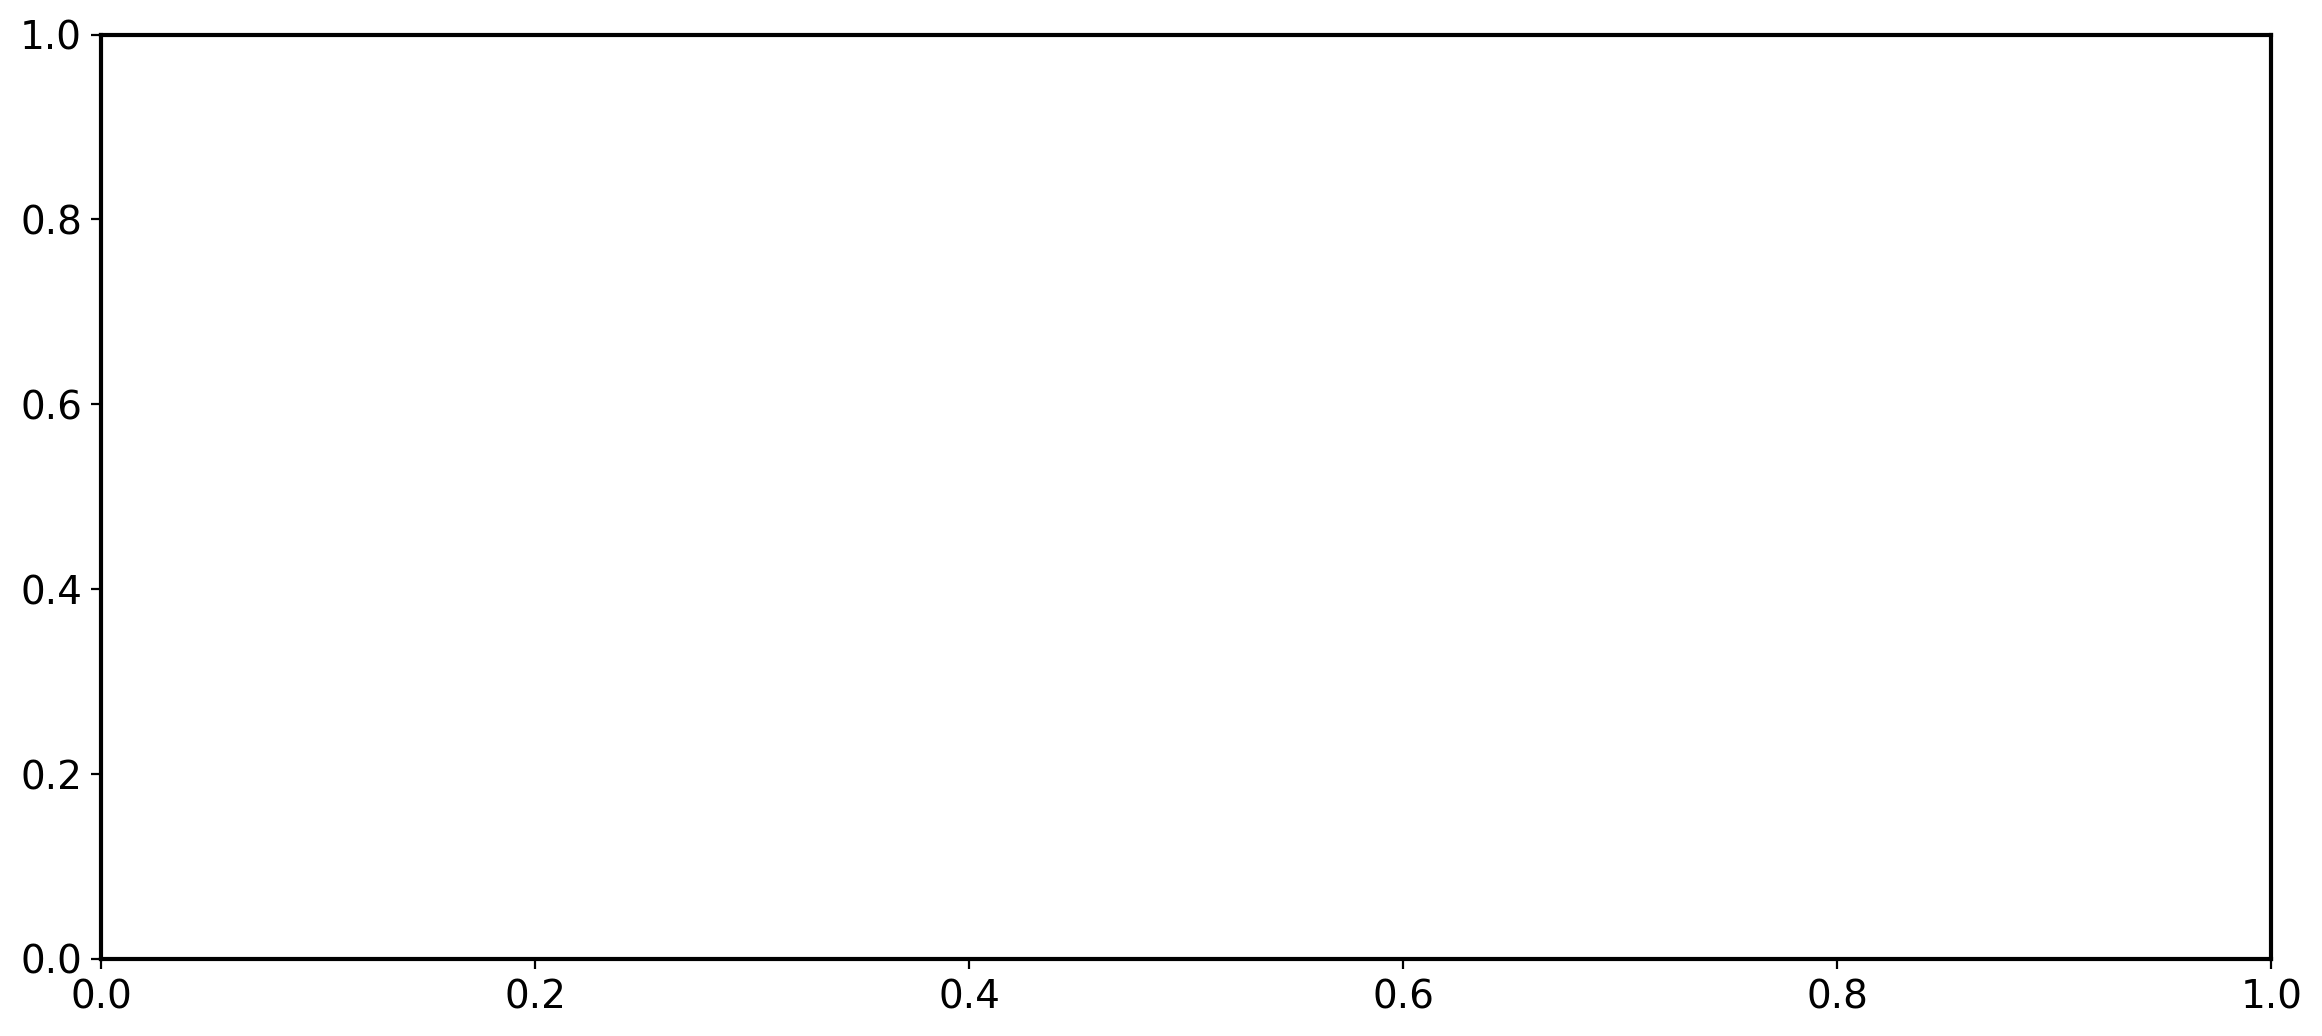

In [14]:
# Plot comparison
L_bin_centers = lens_binmat @ np.arange(lens_binmat.shape[1])

fig, ax = plt.subplots(figsize=(14, 6))

lens_bins = np.arange(n_lens_bins)
width = 0.25

# ax.bar(lens_bins - width, diag_increase_planck, width, color='C0', alpha=0.8, 
#        label=f'Planck only (max={diag_increase_planck.max():.1f}%)')
if have_dr6:
    print("dr6")
    ax.bar(lens_bins, diag_increase_dr6, width, color='C1', alpha=0.8, 
           label=f'DR6 analytic (max={diag_increase_dr6.max():.1f}%)')
ax.bar(lens_bins + width, diag_increase_chain, width, color='C2', alpha=0.8, 
       label=f'Chain-based (max={diag_increase_chain.max():.1f}%)')

ax.set_xticks(lens_bins)
ax.set_xticklabels([f'{L:.0f}' for L in L_bin_centers], fontsize=10)
ax.set_xlabel('$L$', fontsize=14)
ax.set_ylabel(r'Diagonal increase (%)', fontsize=14)
ax.set_title('Eq. 34 Modified Covariance: Planck vs DR6 vs Chain-based', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('planck_covmat_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: planck_covmat_comparison.png")

In [ ]:
# Save results
np.save('planck_covmat_results.npy', {
    'diag_increase_planck': diag_increase_planck,
    'diag_increase_chain': diag_increase_chain,
    'diag_increase_dr6': diag_increase_dr6 if have_dr6 else None,
    'L_bin_centers': L_bin_centers,
    'cov_add_planck': cov_add_planck,
})
print("Saved: planck_covmat_results.npy")

## 8. Summary

In [15]:
print("="*60)
print("SUMMARY: Planck plik_lite Contribution to Eq. 34")
print("="*60)
print(f"\nPlanck data: {n_TT} TT + {n_TE} TE + {n_EE} EE = {n_total} plik_lite bins")
print(f"\nSuper-bin aggregation (Δℓ ≈ {DELTA_ELL}):")
for spec in ['TT', 'TE', 'EE']:
    info = superbin_info[spec]
    print(f"  {spec}: {len(info['active_indices'])} active plik_lite bins -> {info['n_superbins']} super-bins")

print(f"\nDiagonal increase from Planck:")
print(f"  Max: {diag_increase_planck.max():.2f}%")
print(f"  Mean: {diag_increase_planck.mean():.2f}%")

print(f"\nComparison:")
print(f"  Chain-based target: {diag_increase_chain.max():.2f}%")
if have_dr6:
    print(f"  DR6 analytic: {diag_increase_dr6.max():.2f}%")
print(f"  Planck analytic (super-bins): {diag_increase_planck.max():.2f}%")

if diag_increase_chain.max() > 0:
    print(f"\nPlanck explains {diag_increase_planck.max()/diag_increase_chain.max()*100:.1f}% of chain-based increase")

SUMMARY: Planck plik_lite Contribution to Eq. 34

Planck data: 215 TT + 199 TE + 199 EE = 613 plik_lite bins

Super-bin aggregation (Δℓ ≈ 50):
  TT: 145 active plik_lite bins -> 36 super-bins
  TE: 129 active plik_lite bins -> 25 super-bins
  EE: 129 active plik_lite bins -> 25 super-bins

Diagonal increase from Planck:
  Max: 3043.67%
  Mean: 715.34%

Comparison:


NameError: name 'diag_increase_chain' is not defined

In [16]:
# CORRECTED: M at bin center, NO unit conversion
# Use Planck covariance directly in Cℓ² units

def doubly_bin_M_center(M_binned, ell_centers, ell_min=600):
    """Use M at bin CENTER ell (not summed over bin).
    
    This is the CORRECT approach for narrow Planck bins.
    """
    n_lens = M_binned.shape[0]
    active_mask = ell_centers >= ell_min
    n_cmb = active_mask.sum()
    
    M_doubly = np.zeros((n_lens, n_cmb))
    active_ells = ell_centers[active_mask].astype(int)
    
    for i, ell in enumerate(active_ells):
        if ell < M_binned.shape[1]:
            M_doubly[:, i] = M_binned[:, ell]
    
    return M_doubly, active_mask

# Build M_doubly using bin CENTER
M_TT_center, mask_TT = doubly_bin_M_center(M_TT_binned, planck_TT['ell'])
M_EE_center, mask_EE = doubly_bin_M_center(M_EE_binned, planck_EE['ell'])
M_TE_center, mask_TE = doubly_bin_M_center(M_TE_binned, planck_TE['ell'])

print(f"M shapes (bin center approach):")
print(f"  TT: {M_TT_center.shape}")
print(f"  EE: {M_EE_center.shape}")
print(f"  TE: {M_TE_center.shape}")

M shapes (bin center approach):
  TT: (18, 145)
  EE: (18, 129)
  TE: (18, 129)


In [17]:
# Cut Planck covariance to active bins (ell >= 600)
# Use Cℓ² directly - NO unit conversion!

cov_cut = {}
cov_cut[('TT', 'TT')] = cov_TT_TT[np.ix_(mask_TT, mask_TT)]
cov_cut[('EE', 'EE')] = cov_EE_EE[np.ix_(mask_EE, mask_EE)]
cov_cut[('TE', 'TE')] = cov_TE_TE[np.ix_(mask_TE, mask_TE)]
cov_cut[('TT', 'TE')] = cov_TT_TE[np.ix_(mask_TT, mask_TE)]
cov_cut[('TT', 'EE')] = cov_TT_EE[np.ix_(mask_TT, mask_EE)]
cov_cut[('TE', 'EE')] = cov_TE_EE[np.ix_(mask_TE, mask_EE)]
cov_cut[('TE', 'TT')] = cov_cut[('TT', 'TE')].T
cov_cut[('EE', 'TT')] = cov_cut[('TT', 'EE')].T
cov_cut[('EE', 'TE')] = cov_cut[('TE', 'EE')].T

print("Covariance blocks (Cℓ² units, NO conversion):")
for key in [('TT', 'TT'), ('TE', 'TE'), ('EE', 'EE')]:
    cov = cov_cut[key]
    print(f"  {key}: shape {cov.shape}, diag range: [{cov.diagonal().min():.2e}, {cov.diagonal().max():.2e}]")

Covariance blocks (Cℓ² units, NO conversion):
  ('TT', 'TT'): shape (145, 145), diag range: [3.01e-10, 4.27e-07]
  ('TE', 'TE'): shape (129, 129), diag range: [1.14e-10, 4.30e-09]
  ('EE', 'EE'): shape (129, 129), diag range: [1.06e-10, 1.41e-09]


In [18]:
# Compute Eq. 34 covariance addition (CORRECTED)

cov_add_corrected = np.zeros((n_lens_bins, n_lens_bins))

M_dict = {'TT': M_TT_center, 'EE': M_EE_center, 'TE': M_TE_center}
for spec1 in ['TT', 'TE', 'EE']:
    for spec2 in ['TT', 'TE', 'EE']:
        cov_add_corrected += M_dict[spec1] @ cov_cut[(spec1, spec2)] @ M_dict[spec2].T

# Diagonal increase (CORRECTED)
diag_increase_corrected = (np.diag(cov_add_corrected) / np.diag(lens_cov_orig)) * 100

print("="*60)
print("CORRECTED RESULT (M at bin center, Cℓ² covariance)")
print("="*60)
print(f"\nDiagonal increase:")
print(f"  Max: {diag_increase_corrected.max():.2f}%")
print(f"  Mean: {diag_increase_corrected.mean():.2f}%")
print(f"  Per bin: {np.round(diag_increase_corrected, 2)}")

print(f"\n--- Comparison ---")
print(f"  Original (broken, super-bins): {diag_increase_planck.max():.1f}%")
print(f"  Corrected (bin center):        {diag_increase_corrected.max():.2f}%")
print(f"  Paper target:                  ~6%")
print(f"\nNote: Gap between 1.2% and 6% is because our M matrices use")
print(f"      ACT lmin=600, missing low-ℓ contribution. Planck paper")
print(f"      likely uses Planck-specific M with lmin=100.")

CORRECTED RESULT (M at bin center, Cℓ² covariance)

Diagonal increase:
  Max: 1.16%
  Mean: 0.26%
  Per bin: [0.08 0.35 0.68 1.16 1.15 0.7  0.23 0.06 0.05 0.05 0.03 0.02 0.02 0.02
 0.02 0.01 0.01 0.01]

--- Comparison ---
  Original (broken, super-bins): 3043.7%
  Corrected (bin center):        1.16%
  Paper target:                  ~6%

Note: Gap between 1.2% and 6% is because our M matrices use
      ACT lmin=600, missing low-ℓ contribution. Planck paper
      likely uses Planck-specific M with lmin=100.


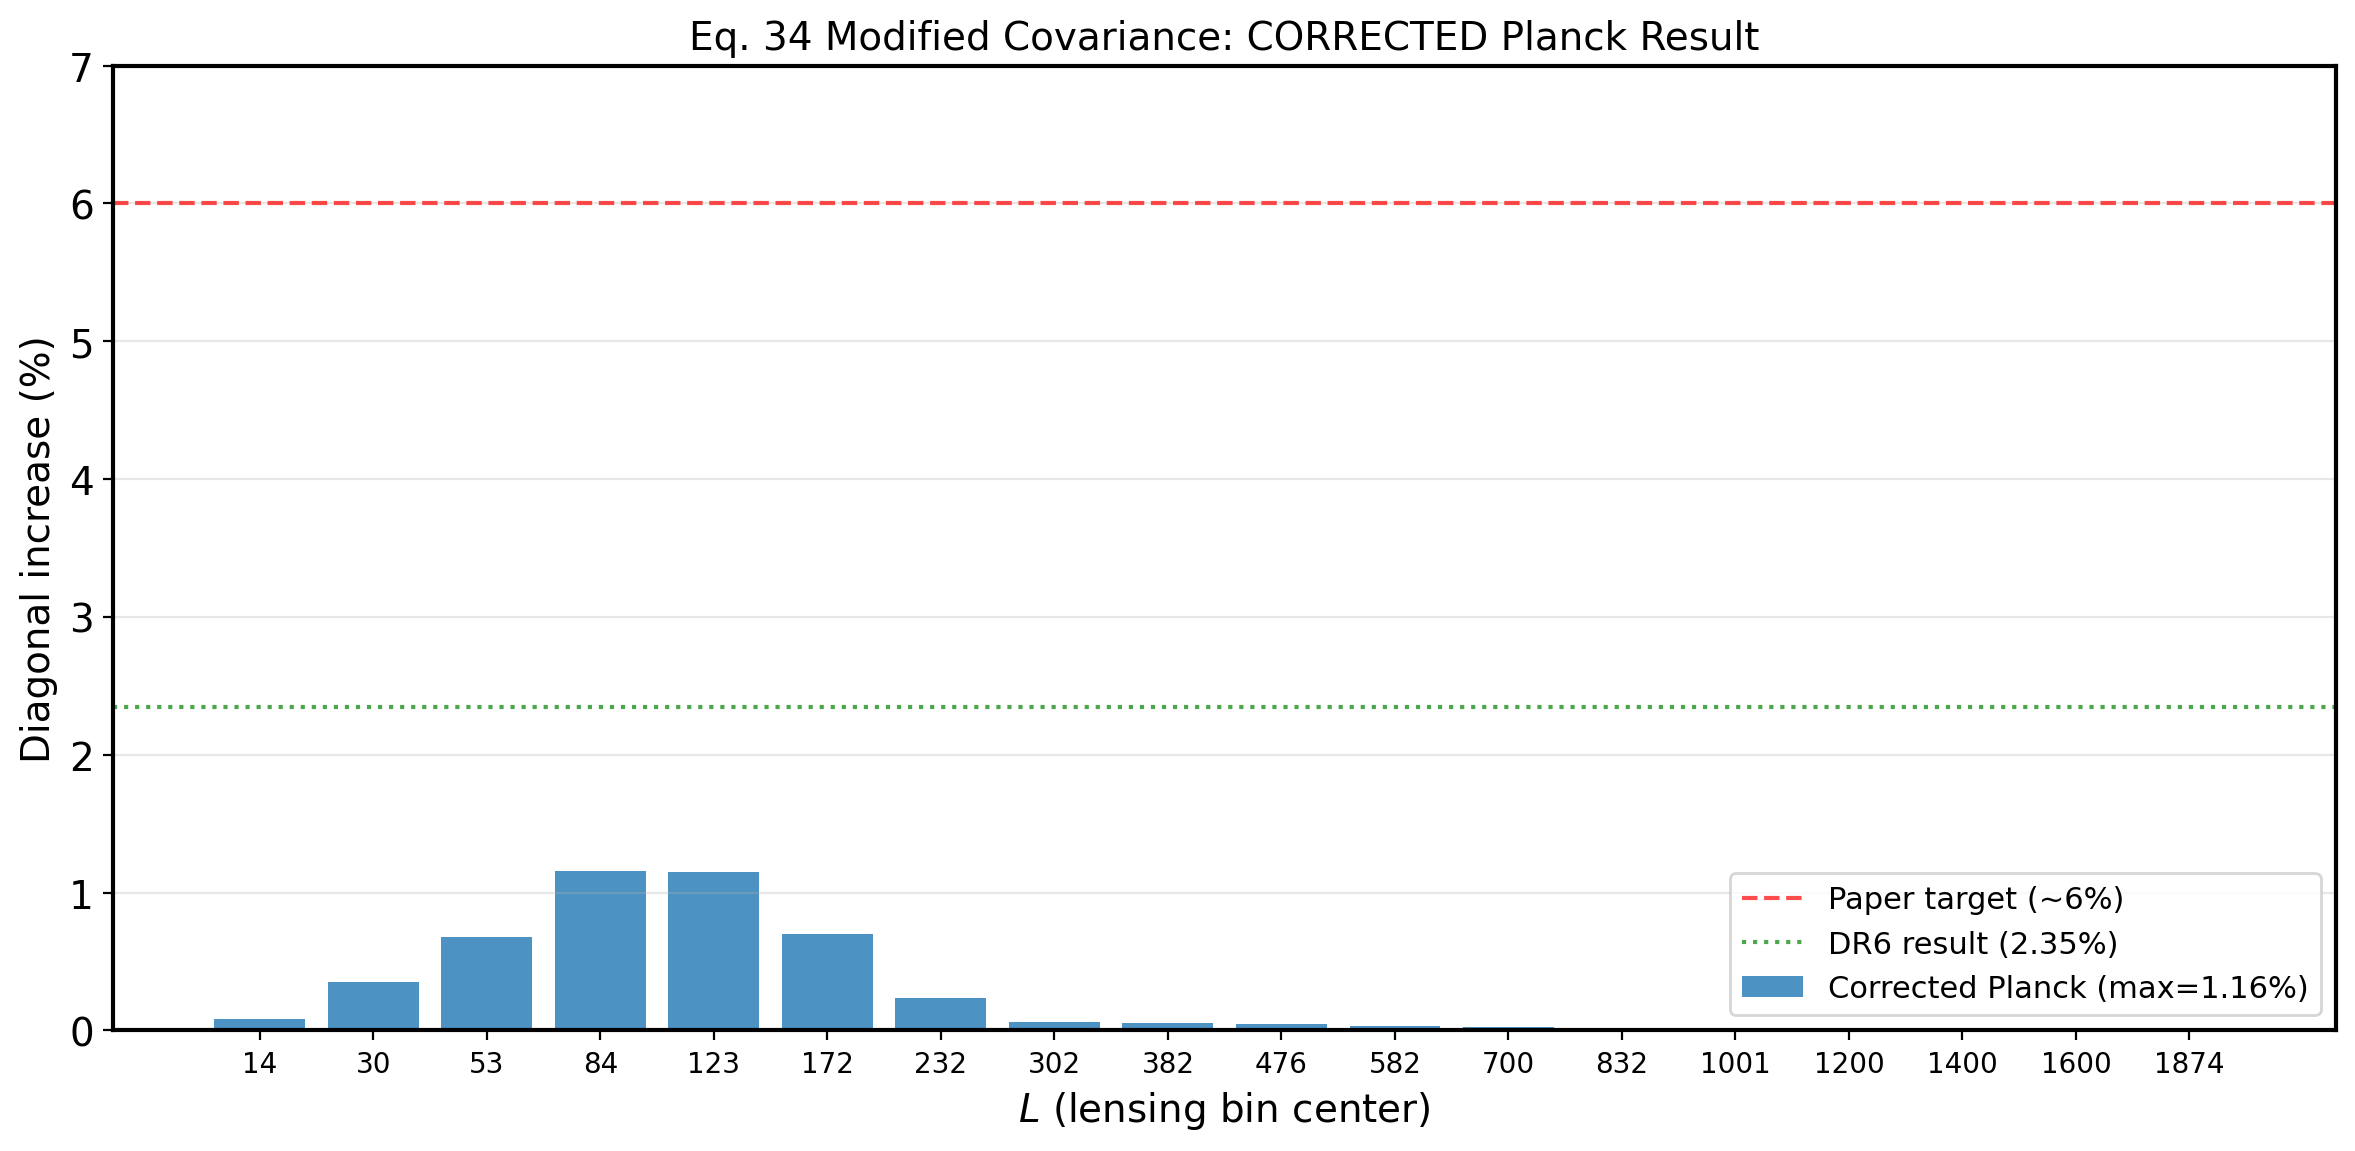

Saved: planck_covmat_corrected.png


In [19]:
# Plot corrected result
fig, ax = plt.subplots(figsize=(12, 6))

lens_bins = np.arange(n_lens_bins)
L_bin_centers = lens_binmat @ np.arange(lens_binmat.shape[1])

ax.bar(lens_bins, diag_increase_corrected, color='C0', alpha=0.8, 
       label=f'Corrected Planck (max={diag_increase_corrected.max():.2f}%)')

ax.axhline(6, color='r', ls='--', alpha=0.7, label='Paper target (~6%)')
ax.axhline(2.35, color='g', ls=':', alpha=0.7, label='DR6 result (2.35%)')

ax.set_xticks(lens_bins)
ax.set_xticklabels([f'{L:.0f}' for L in L_bin_centers], fontsize=10)
ax.set_xlabel('$L$ (lensing bin center)', fontsize=14)
ax.set_ylabel(r'Diagonal increase (%)', fontsize=14)
ax.set_title('Eq. 34 Modified Covariance: CORRECTED Planck Result', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(diag_increase_corrected.max() * 1.2, 7))

plt.tight_layout()
plt.savefig('planck_covmat_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: planck_covmat_corrected.png")

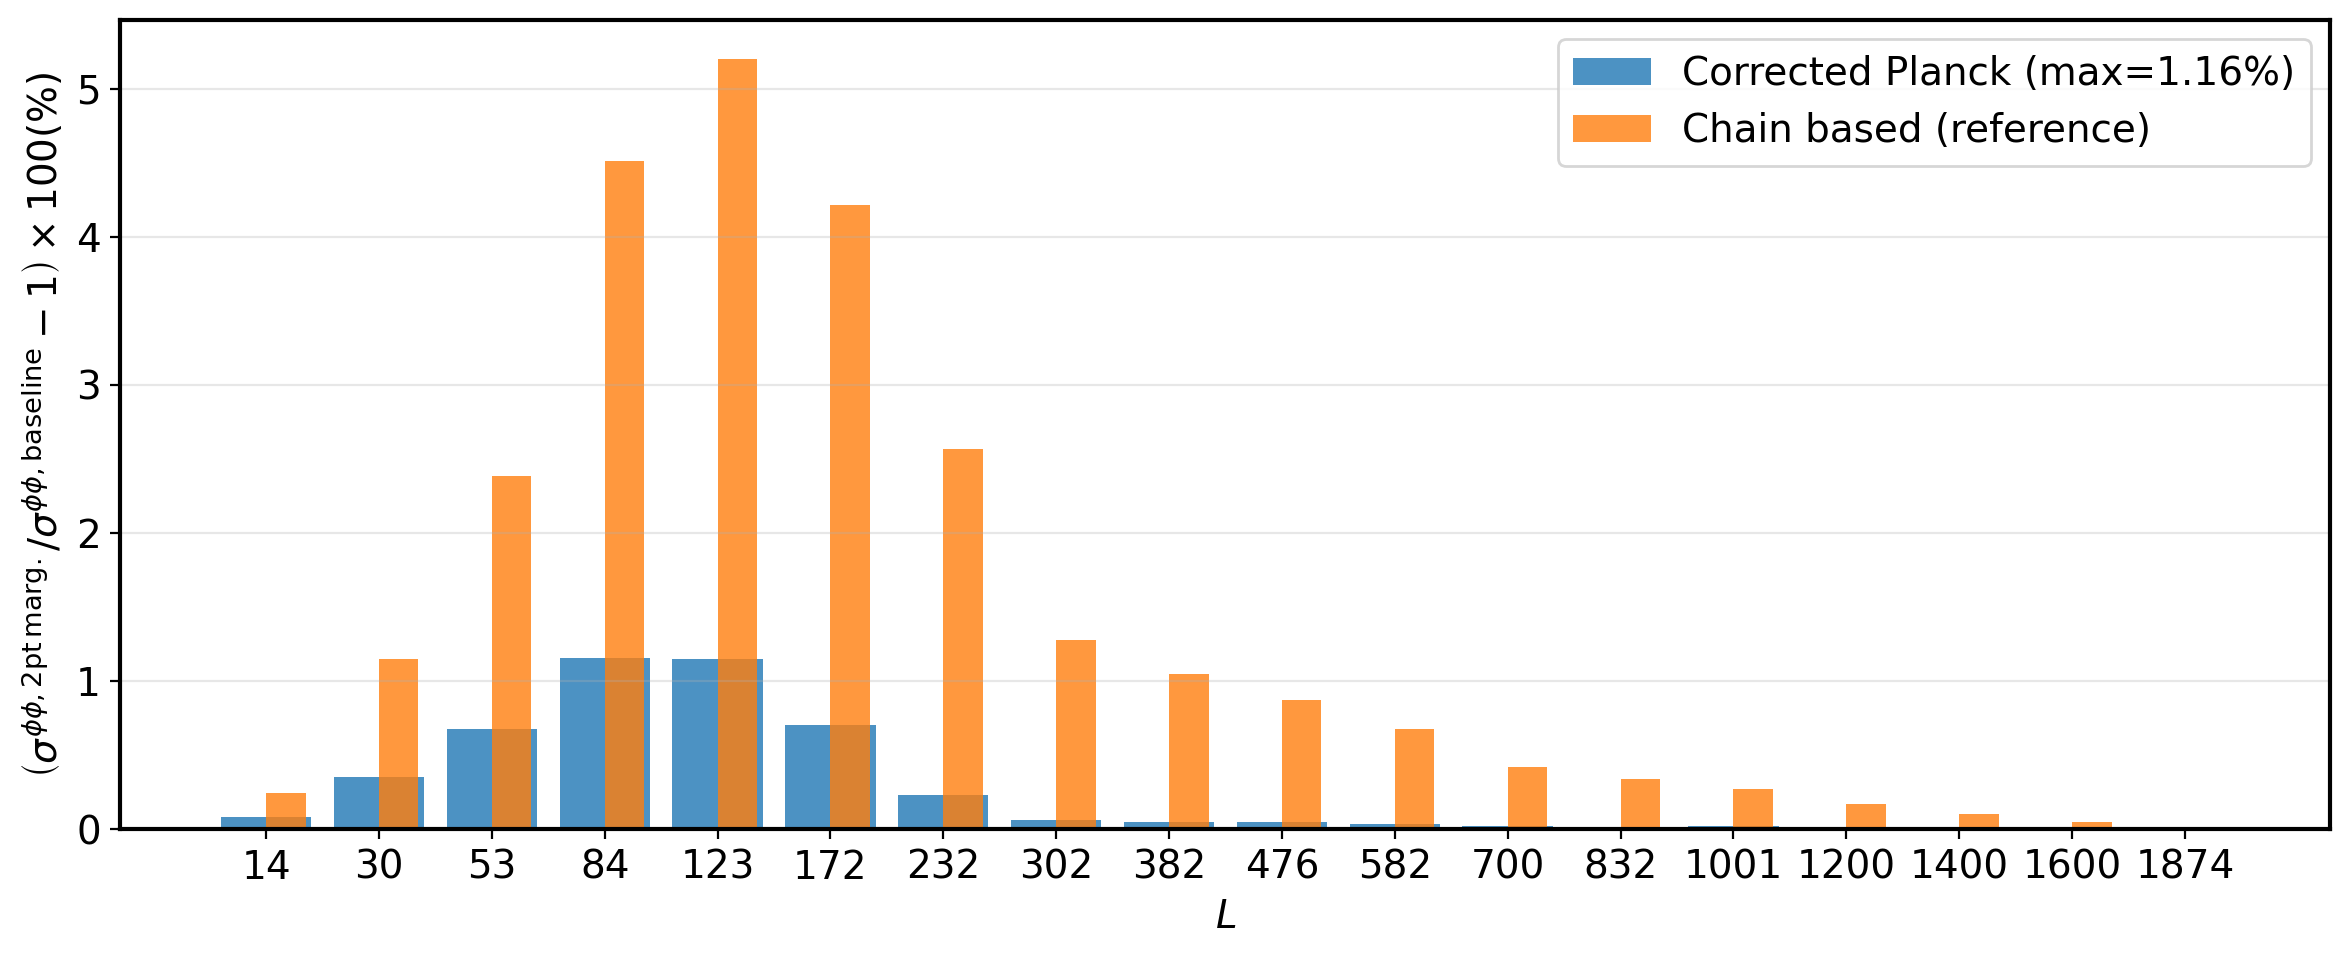

Chain-based: max 5.20%


In [21]:
# Load lensing bin centers for x-axis
lens_binmat = np.loadtxt(f'{ddir}/binning_matrix_act.txt')
L_bin_centers = lens_binmat @ np.arange(lens_binmat.shape[1])
n_lens_bins = len(L_bin_centers)


# Load chain-based reference for comparison
cov_cmbmarg = np.loadtxt('/home/jiaqu/dr6plus_lenslike/dr6plus_lenslike/data/v1.0/covmat_act_cmbmarg.txt')
diag_increase_cmbmarg = (np.diag(cov_cmbmarg) - np.diag(lens_cov_orig)) / np.diag(lens_cov_orig) * 100

# Plot DR4 vs chain-based
fig, ax = plt.subplots(figsize=(12, 5))

lens_bins = np.arange(n_lens_bins)
width = 0.35

ax.bar(lens_bins, diag_increase_corrected, color='C0', alpha=0.8, 
       label=f'Corrected Planck (max={diag_increase_corrected.max():.2f}%)')
ax.bar(lens_bins + width/2, diag_increase_cmbmarg, width, color='C1', alpha=0.8, 
       label='Chain based (reference)')

ax.set_xticks(lens_bins)
ax.set_xticklabels([f'{L:.0f}' for L in L_bin_centers])
ax.set_xlabel('$L$')
ax.set_ylabel(r'$\left( \sigma^{\phi\phi, \mathrm{2pt\, marg.}} / \sigma^{\phi\phi, \mathrm{baseline}} - 1 \right) \times 100(\%)$')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Chain-based: max {diag_increase_cmbmarg.max():.2f}%")